<a href="https://colab.research.google.com/github/rtealwitter/dl-demos/blob/main/demo11-conditional-gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conditional GANs

Based on the excellent tutorial [here](https://github.com/Yangyangii/GAN-Tutorial/blob/master/MNIST/Conditional-GAN.ipynb).

By formulating the process as a two-player game, Generative Adversarial Networks (GANs) can be very effective in generating realistic content. However, we may want to have more control over what is generated. Conditional GANs offer more control by letting us specify the *class* of output we want. Then we hand the generated content and the class it's supposed to be to the discriminator. The disciminator attempts to differentiate between the generated content of a certain class and the real content of a certain class.

The original paper that described conditional GANs is [here](https://arxiv.org/abs/1411.1784).

![](https://salu133445.github.io/dan/figs/cgan.png)


## Libaries

As always, we load lots of libraries.

In [1]:
import torch
from torchvision import datasets
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import os
from matplotlib.pyplot import imsave
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Data

For this demo, we will be using the MNIST data set. We can apply GANs to other datasets but the training process takes much longer. Our goal will be to supply random noise and a class label (e.g. a digit between 0 and 9) to the generator and produce an image of that particular digit.

In [2]:
# A transform to convert the images to tensor and normalize their RGB values
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5], std=[0.5])]
)

data = datasets.FashionMNIST(root='../data/', train=True, transform=transform, download=True)   # modified to fashionMINIST

batch_size = 64
data_loader = DataLoader(dataset=data, batch_size=batch_size, shuffle=True, drop_last=True)

## Helper Functions

We'll need several helper functions for training the conditional GAN. The first converts labels to one hot encoded vectors, we will use it to pass the desired label to the generator. The second will plot a grid of 10x10 images from the generator.

In [3]:
def get_sample_image(G, DEVICE, n_noise=100):
    img = np.zeros([280, 280])
    for j in range(10):
        z = torch.randn(10, n_noise).to(DEVICE)
        y_hat = G(z).view(10, 28, 28)
        result = y_hat.cpu().data.numpy()
        img[j*28:(j+1)*28] = np.concatenate([x for x in result], axis=-1)
    return img

## Architecture

We now instantiate the generator and discriminator architectures. The generator takes a random noise vector and a one hot encoded label as input and produces an image. The discriminator takes an image and a one hot encoded label as input and produces a single value between 0 and 1. The discriminator is trained to output 1 for real images and 0 for fake images. The generator is trained to fool the discriminator by outputting images that look real.

In [4]:
class Generator(nn.Module):
    def __init__(self, input_size=100, image_size=28*28):
        super(Generator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128), # removed the label
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        # removed class-related op's.
        # v = torch.cat((x, c), 1) # v: [input, label] concatenated vector
        y_ = self.network(x)
        y_ = y_.view(x.size(0), 1, 28, 28)
        return y_

In [5]:
class Discriminator(nn.Module):
    def __init__(self, input_size=28*28, num_output=1):
        super(Discriminator, self).__init__()
        self.network = nn.Sequential(
            # here we removed classes
            nn.Linear(input_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, num_output),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x= x.view(x.size(0), -1)
        # v = torch.cat((x, c), 1) # v: [input, label] concatenated vector
        y_ = self.network(x)
        return y_

## Set up and Training

Now, we're ready to instantiate our models, hyperparameters, and optimizers. Since the task is so easy for MNIST, we will train for only 10 epochs. We will update the generator and discriminator in every step but often one can be trained more frequently than the other.

In [6]:
MODEL_NAME = 'GAN'
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

D = Discriminator().to(DEVICE) # randomly intialized
G = Generator().to(DEVICE) # randomly initialized

max_epoch = 10
step = 0
n_noise = 100 # size of noise vector

criterion = nn.BCELoss()
D_opt = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
G_opt = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

# We will denote real images as 1s and fake images as 0s
# This is why we needed to drop the last batch of the data loader
all_ones = torch.ones([batch_size, 1]).to(DEVICE) # Discriminator label: real
all_zeros = torch.zeros([batch_size, 1]).to(DEVICE) # Discriminator Label: fake

In [7]:
"""images, class_labels = next(iter(data_loader))
class_labels_encoded = class_labels.view(batch_size, 1)
class_labels_encoded = to_onehot(class_labels_encoded).to(DEVICE)
print(class_labels[:10])
print(class_labels_encoded[:10])"""

# GET one batch of data
images, _ = next(iter(data_loader))

# check shape
print(images.shape)

torch.Size([64, 1, 28, 28])


In [8]:
# a directory to save the generated images
if not os.path.exists('samples'):
    os.makedirs('samples')

for epoch in range(max_epoch):
    # 修改1: 用 _ 忽略掉 class_labels
    for idx, (images, _) in enumerate(data_loader):
        x = images.to(DEVICE)

        # 修改2: 删除 label 处理代码
        # class_labels = class_labels.view(batch_size, 1)
        # class_labels = to_onehot(class_labels).to(DEVICE)

        x_outputs = D(x)
        D_x_loss = criterion(x_outputs, all_ones) # Discriminator loss for real images

        z = torch.randn(batch_size, n_noise).to(DEVICE)

        z_outputs = D(G(z))
        D_z_loss = criterion(z_outputs, all_zeros) # Discriminator loss for fake images
        D_loss = D_x_loss + D_z_loss # Total Discriminator loss

        D.zero_grad()
        D_loss.backward()
        D_opt.step()

        # Training Generator
        z = torch.randn(batch_size, n_noise).to(DEVICE)

        z_outputs = D(G(z))
        G_loss = -1 * criterion(z_outputs, all_zeros) # Generator loss is negative disciminator loss

        G.zero_grad()
        G_loss.backward()
        G_opt.step()

        if step % 500 == 0:
            print('Epoch: {}/{}, Step: {}, D Loss: {}, G Loss: {}'.format(epoch, max_epoch, step, D_loss.item(), G_loss.item()))

        if step % 1000 == 0:
            G.eval()
            img = get_sample_image(G, DEVICE, n_noise)
            imsave('samples/{}_step{}.jpg'.format(MODEL_NAME, str(step).zfill(3)), img, cmap='gray')
            G.train()
        step += 1

Epoch: 0/10, Step: 0, D Loss: 1.413398265838623, G Loss: -0.678968071937561
Epoch: 0/10, Step: 500, D Loss: 1.2285442352294922, G Loss: -0.4876769185066223
Epoch: 1/10, Step: 1000, D Loss: 1.1210567951202393, G Loss: -0.40207844972610474
Epoch: 1/10, Step: 1500, D Loss: 1.5181331634521484, G Loss: -0.3948204815387726
Epoch: 2/10, Step: 2000, D Loss: 1.2950239181518555, G Loss: -0.6324476003646851
Epoch: 2/10, Step: 2500, D Loss: 1.2897183895111084, G Loss: -0.4195989668369293
Epoch: 3/10, Step: 3000, D Loss: 1.4309463500976562, G Loss: -0.5767621994018555
Epoch: 3/10, Step: 3500, D Loss: 1.2801183462142944, G Loss: -0.6176079511642456
Epoch: 4/10, Step: 4000, D Loss: 1.19602632522583, G Loss: -0.5222233533859253
Epoch: 4/10, Step: 4500, D Loss: 1.377496600151062, G Loss: -0.5191594362258911
Epoch: 5/10, Step: 5000, D Loss: 1.3128511905670166, G Loss: -0.5169262886047363
Epoch: 5/10, Step: 5500, D Loss: 1.3391191959381104, G Loss: -0.5578123927116394
Epoch: 6/10, Step: 6000, D Loss: 1.3

Now let's plot these images. At first, the generator just produces noise (as we expect).

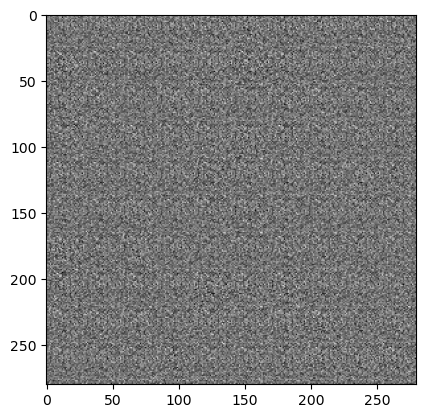

In [9]:
img = mpimg.imread('samples/GAN_step000.jpg')
imgplot = plt.imshow(img)
plt.show()

But then it gets better.

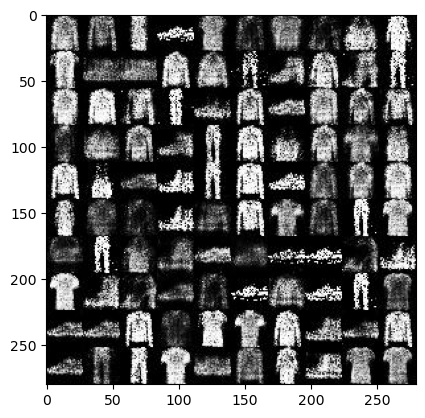

In [10]:
img = mpimg.imread('samples/GAN_step5000.jpg')
imgplot = plt.imshow(img)
plt.show()

In fact, if we don't look too closely, we can recognize the numbers it produces.

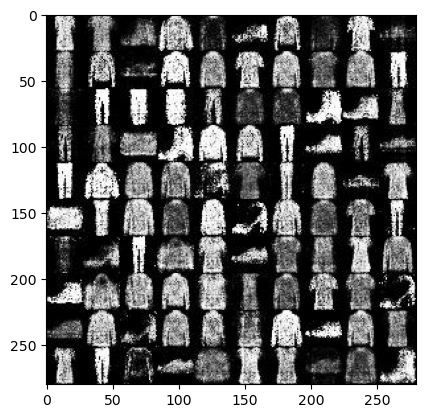

In [11]:
img = mpimg.imread('samples/GAN_step9000.jpg')
imgplot = plt.imshow(img)
plt.show()

Real Image Library built. Shape: torch.Size([200, 784])
Starting batch generation and distance calculation...

====== Evaluation Report (N=200) ======
Mean Nearest Neighbor Distance: 11.5092
Standard Deviation: 2.2875
Note: Lower distance implies generated images are closer to the real data manifold.
      However, if distance is extremely close to 0, check for overfitting (memorization).


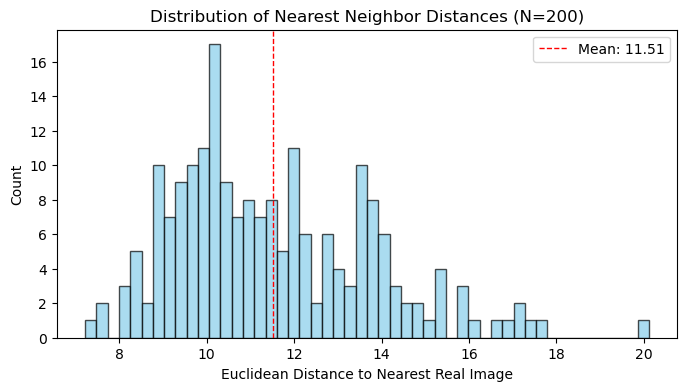

In [12]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Set Sample Size
# ==========================================
N_SAMPLES = 200  # Collect 2000 images for large-scale comparison
BATCH_SIZE_EVAL = 100 # Process 100 fake images at a time to prevent memory issues

print(f"Collecting {N_SAMPLES} real images to build the 'Real Image Library'...")

# ==========================================
# 2. Build Real Image Library
# ==========================================
real_imgs_list = []
for images, _ in data_loader:
    real_imgs_list.append(images)
    # Stop once we have enough images
    if len(real_imgs_list) * 64 >= N_SAMPLES:
        break

# Concatenate and slice to get exactly N_SAMPLES
real_library = torch.cat(real_imgs_list, dim=0)[:N_SAMPLES].to(DEVICE)
# Flatten to [N_SAMPLES, 784] for distance calculation
real_library_flat = real_library.view(N_SAMPLES, -1)

print(f"Real Image Library built. Shape: {real_library_flat.shape}")

# ==========================================
# 3. Batch Generate Fake Images & Calculate NN Distance
# ==========================================
print("Starting batch generation and distance calculation...")

min_distances = [] # List to store the minimum distance for each fake image

# Loop through batches to avoid OOM (Out Of Memory)
for i in range(0, N_SAMPLES, BATCH_SIZE_EVAL):
    # A. Generate a batch of fake images
    z = torch.randn(BATCH_SIZE_EVAL, n_noise).to(DEVICE)
    fake_imgs = G(z).detach() # [100, 1, 28, 28]
    fake_imgs_flat = fake_imgs.view(BATCH_SIZE_EVAL, -1) # Flatten to [100, 784]

    # B. Calculate Distance Matrix [100, 2000]
    # Computes distance between every fake image in this batch and every real image in the library
    dists_batch = torch.cdist(fake_imgs_flat, real_library_flat, p=2)

    # C. Find the nearest neighbor for each fake image
    # min(dim=1) returns (values, indices)
    batch_min_dists, _ = torch.min(dists_batch, dim=1)

    # Store the results
    min_distances.append(batch_min_dists.cpu())

# Concatenate results from all batches
all_min_dists = torch.cat(min_distances)
avg_nn_dist = torch.mean(all_min_dists).item()
std_nn_dist = torch.std(all_min_dists).item()

# ==========================================
# 4. Report and Visualization
# ==========================================
print(f"\n====== Evaluation Report (N={N_SAMPLES}) ======")
print(f"Mean Nearest Neighbor Distance: {avg_nn_dist:.4f}")
print(f"Standard Deviation: {std_nn_dist:.4f}")
print(f"Note: Lower distance implies generated images are closer to the real data manifold.")
print(f"      However, if distance is extremely close to 0, check for overfitting (memorization).")

# Plot Histogram
plt.figure(figsize=(8, 4))
plt.hist(all_min_dists.numpy(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f"Distribution of Nearest Neighbor Distances (N={N_SAMPLES})")
plt.xlabel("Euclidean Distance to Nearest Real Image")
plt.ylabel("Count")
plt.axvline(avg_nn_dist, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {avg_nn_dist:.2f}')
plt.legend()
plt.show()